# 🧬 PhyloMethod: 系統樹推定手法の網羅的ベンチマーク解析ノートブック
### Pairwise Sequence Alignment + Neighbor-Joining (PSA+NJ) vs Multiple Sequence Alignment + Maximum Likelihood (MSA+ML) / MSA+NJ / FastME

本ノートブックは、大規模進化シミュレーションにより得られた系統樹推定ベンチマーク結果（実験1〜実験10）を統合・統計分析・可視化し、さらに全実験・全条件における example シミュレーション（True Tree, True MSA, 推定 Tree 等）および配列類似度（Sequence Similarity/Identity）を検証するための網羅的解析環境です。

---

### 📊 実験設計と検証項目一覧

| 実験 | 名称 | 主要パラメータ | 置換モデル / 距離モデル | 検証パイプライン | 目的 |
|---|---|---|---|---|---|
| **実験1** | 基本パラメータ空間 | $D \in [0.1..3.0]$, $L \in [100..1500]$, $N=32$ | `LG+G4` ($\alpha=1.0$), Poisson | `PSA+NJ`, `MSA+NJ`, `MSA+ML`, `TRUE_DIST+NJ`, `TRUE_MSA+NJ`, `TRUE_MSA+ML` | 距離×配列長空間における Regime Map と各手法のトポロジー精度解明 |
| **実験2** | Taxon数スケーリング | $N \in [8, 16, 64, 128]$, $D \times L$ | `LG+G4`, Poisson | `PSA+NJ`, `MSA+NJ`, `MSA+ML` | Taxon 数増加に対するスケーラビリティと推定精度の推移 |
| **実験3** | サイト間速度不均一性 | $\alpha \in [0.25, 0.5, 1.0, 2.0]$, $D \times L$ | `LG+G4`, Poisson | `PSA+NJ`, `MSA+NJ`, `MSA+ML` | ガンマ形状母数 $\alpha$（不均一性の強さ）に対する各手法の頑健性 |
| **実験4** | 真のPSAアライメント | $D \times L$, $N=32$ | `LG+G4`, Poisson | `TRUE_PSA+NJ` | ペアワイズアライメント誤差を排除した理想的PSAの精度検証 |
| **実験5** | ガンマ補正距離 | $\alpha \in [0.25..2.0]$, $D \times L$ | `LG+G4`, `gamma_poisson` ($\alpha_{\text{dist}}=1.0$) | `PSA+NJ`, `MSA+NJ`, `MSA+ML` | ガンマ補正距離による距離法の精度変化の検証 |
| **実験6** | ICS (短縮・切断配列) | $\mathrm{ics\_prop} \in [0.0..0.2]$, $D \times L$ | `LG+G4_ICS`, Poisson | `PSA+NJ`, `MSA+NJ`, `MSA+ML` | 内部切断・ドメイン欠落（Invariant Category Sites）への耐性 |
| **実験7** | FastME 距離法比較 (NoOption) | $D \times L$, $N=32$ | `LG+G4`, Poisson | `PSA+FastME_NoOption`, `MSA+FastME_NoOption` | 距離法アルゴリズム（FastME vs RapidNJ）の比較 |
| **実験8** | 高進化距離領域 | $D \in [4.0, 5.0, 6.0]$, $L \in [300..1500]$ | `LG+G4`, Poisson | `PSA+NJ`, `MSA+NJ`, `MSA+ML` | 超高変異領域における飽和現象と各手法の限界 |
| **実験9** | 単一均一置換モデル | $D \times L$, $N=32$ | `LG` (均一速度), Poisson | `PSA+NJ`, `MSA+NJ`, `MSA+ML` | サイト間均一環境におけるパイプライン比較 |
| **実験10** | FastME オプション比較 | $D \in [0.1..6.0]$, $L \in [300..1500]$, $N=32$ | `LG+G4`, Poisson / Gamma | `PSA+FastME_SPR`, `MSA+FastME_LG_G` | FastME 最適化オプション（SPR 近傍探索 / ガンマ距離モデル）のトポロジー精度検証 |

---
## 1. 環境セットアップ & ライブラリインポート

In [1]:
%matplotlib inline
import os
import sys
import glob
import subprocess
import shutil
import warnings
import itertools
import json
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats

import dendropy
from dendropy.calculate import treecompare
import Bio
from Bio import Phylo, SeqIO

# ワーニング非表示
warnings.filterwarnings('ignore')

# 描画スタイル & グローバルフォントサイズ設定
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'Hiragino Sans', 'Yu Gothic']
plt.rcParams.update({
    'font.size': 11,              # 全体の基本フォントサイズ
    'figure.titlesize': 14,       # 全体タイトル (plt.suptitle) のサイズ
    'axes.titlesize': 12,         # サブプロットのタイトル (ax.set_title) のサイズ
    'axes.labelsize': 11,         # 軸ラベル (X軸・Y軸のラベル) のサイズ
    'xtick.labelsize': 10,        # X軸の目盛り数値のサイズ
    'ytick.labelsize': 10,        # Y軸の目盛り数値のサイズ
    'legend.fontsize': 10,        # 凡例のテキストサイズ
    'legend.title_fontsize': 11,  # 凡例のタイトルサイズ
    'figure.dpi': 120,
    'savefig.dpi': 300
})

# micromamba / conda 環境の PATH を設定（mafft, rapidnj, fastme, iqtree が実行できるように設定）
env_bin_paths = [
    "/opt/homebrew/Cellar/micromamba/2.8.1/envs/phylomethod_env/bin",
    os.path.expanduser("~/miniconda3/envs/phylomethod_env/bin"),
    os.path.expanduser("~/miniforge3/envs/phylomethod_env/bin"),
    os.path.expanduser("~/micromamba/envs/phylomethod_env/bin"),
    "/opt/homebrew/bin",
    os.path.expanduser("~/bin")
]
for p in env_bin_paths:
    if os.path.isdir(p) and p not in os.environ["PATH"]:
        os.environ["PATH"] = p + ":" + os.environ["PATH"]

# プロジェクトパスの設定
PROJECT_ROOT = Path(os.path.abspath("..")) if os.path.exists("../results") else Path(os.path.abspath("."))
RESULTS_DIR = PROJECT_ROOT / "results"
ANALYSIS_DIR = PROJECT_ROOT / "analysis"
EXAMPLE_DIR = ANALYSIS_DIR / "example"
SIMILARITY_DIR = ANALYSIS_DIR / "similarity"
EXAMPLE_DIR.mkdir(parents=True, exist_ok=True)
SIMILARITY_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project Root   : {PROJECT_ROOT}")
print(f"Results Dir    : {RESULTS_DIR}")
print(f"Analysis Dir   : {ANALYSIS_DIR}")
print(f"Example Dir    : {EXAMPLE_DIR}")
print(f"Similarity Dir : {SIMILARITY_DIR}")

# 外部ツール検出確認
tools = ["mafft", "rapidnj", "fastme", "iqtree", "iqtree2"]
for t in tools:
    path = shutil.which(t)
    status = f"✓ ({path})" if path else "✗ Not found in PATH"
    print(f"  {t:<10}: {status}")

Project Root   : /Users/aibarakazuki/PhyloTree_Methods_Comparison
Results Dir    : /Users/aibarakazuki/PhyloTree_Methods_Comparison/results
Analysis Dir   : /Users/aibarakazuki/PhyloTree_Methods_Comparison/analysis
Example Dir    : /Users/aibarakazuki/PhyloTree_Methods_Comparison/analysis/example
Similarity Dir : /Users/aibarakazuki/PhyloTree_Methods_Comparison/analysis/similarity
  mafft     : ✓ (/Users/aibarakazuki/.micromamba/envs/phylomethod_env/bin/mafft)
  rapidnj   : ✓ (/Users/aibarakazuki/.micromamba/envs/phylomethod_env/bin/rapidnj)
  fastme    : ✓ (/Users/aibarakazuki/.micromamba/envs/phylomethod_env/bin/fastme)
  iqtree    : ✓ (/Users/aibarakazuki/.micromamba/envs/phylomethod_env/bin/iqtree)
  iqtree2   : ✗ Not found in PATH


---
## 2. ベンチマーク結果の集約 & 統一スキーマへの統合

各実験ディレクトリから `*_summary.csv` を読み込み、実験ごとに異なっているカラム構成を共通スキーマに正規化して結合します。
- パイプライン名の **`PWA` をすべて `PSA`（Pairwise Sequence Alignment）に統一** します。
- 実験7の FastME については `FastME` $\to$ `FastME_NoOption` に統一します。
- 実験10の FastME オプション結果（`PSA+FastME_SPR`, `MSA+FastME_LG_G`）も統合します。
- 統合したデータフレームを `analysis/all_experiments_summary.csv` として出力します。

In [2]:
def load_and_unify_benchmark_results(results_dir=RESULTS_DIR):
    """
    resultsディレクトリ配下の全実験結果CSVを読み込み、統一スキーマに変換して統合する。
    """
    true_psa_path = results_dir / "results_true_psa" / "benchmark_true_psa_summary.csv"
    if not true_psa_path.exists():
        true_psa_path = results_dir / "results_true_pwa" / "benchmark_true_pwa_summary.csv"

    experiment_configs = [
        {
            "id": "Exp1_Default",
            "name": "Exp1: D x L Base (LG+G4)",
            "path": results_dir / "results_default" / "benchmark_summary.csv",
            "defaults": {
                "num_taxa": 32,
                "alpha": 1.0,
                "ics_prop": 0.0,
                "dist_model": "poisson",
                "model": "LG+G4",
            }
        },
        {
            "id": "Exp2_Taxon",
            "name": "Exp2: Taxon Scaling",
            "path": results_dir / "results_taxon" / "benchmark_taxon_summary.csv",
            "defaults": {
                "alpha": 1.0,
                "ics_prop": 0.0,
                "dist_model": "poisson",
                "model": "LG+G4",
            }
        },
        {
            "id": "Exp3_Alpha",
            "name": "Exp3: Rate Heterogeneity (alpha)",
            "path": results_dir / "results_alpha" / "benchmark_alpha_summary.csv",
            "defaults": {
                "num_taxa": 32,
                "ics_prop": 0.0,
                "dist_model": "poisson",
                "model": "LG+G4",
            }
        },
        {
            "id": "Exp4_TruePSA",
            "name": "Exp4: True PSA+NJ",
            "path": true_psa_path,
            "defaults": {
                "num_taxa": 32,
                "alpha": 1.0,
                "ics_prop": 0.0,
                "dist_model": "poisson",
                "model": "LG+G4",
            }
        },
        {
            "id": "Exp5_Gamma",
            "name": "Exp5: Gamma Distance (gamma_poisson)",
            "path": results_dir / "results_gamma" / "benchmark_gamma_summary.csv",
            "defaults": {
                "num_taxa": 32,
                "ics_prop": 0.0,
                "dist_model": "gamma_poisson",
                "model": "LG+G4",
            }
        },
        {
            "id": "Exp6_ICS",
            "name": "Exp6: Invariant Category Sites (ICS)",
            "path": results_dir / "results_ics" / "benchmark_ics_summary.csv",
            "defaults": {
                "num_taxa": 32,
                "alpha": 1.0,
                "dist_model": "poisson",
                "model": "LG+G4_ICS",
            }
        },
        {
            "id": "Exp7_FastME",
            "name": "Exp7: FastME vs NJ (NoOption)",
            "path": results_dir / "results_fastme_NoOption" / "benchmark_fastme_summary.csv",
            "defaults": {
                "num_taxa": 32,
                "alpha": 1.0,
                "ics_prop": 0.0,
                "dist_model": "poisson",
                "model": "LG+G4",
            },
            "pipeline_rename": {
                "PWA+FastME": "PSA+FastME_NoOption",
                "PSA+FastME": "PSA+FastME_NoOption",
                "MSA+FastME": "MSA+FastME_NoOption"
            }
        },
        {
            "id": "Exp8_HighDist",
            "name": "Exp8: High Distance (D=4.0-6.0)",
            "path": results_dir / "results_high_dist" / "benchmark_high_dist_summary.csv",
            "defaults": {
                "num_taxa": 32,
                "alpha": 1.0,
                "ics_prop": 0.0,
                "dist_model": "poisson",
                "model": "LG+G4",
            }
        },
        {
            "id": "Exp9_SimpleLG",
            "name": "Exp9: Homogeneous Model (LG)",
            "path": results_dir / "results_simple" / "benchmark_high_dist_summary.csv",
            "defaults": {
                "num_taxa": 32,
                "alpha": 1.0,
                "ics_prop": 0.0,
                "dist_model": "poisson",
                "model": "LG",
            }
        },
        {
            "id": "Exp10_FastMEOptions",
            "name": "Exp10: FastME Options (SPR / LG+G)",
            "path": results_dir / "results_fastme_options" / "benchmark_fastme_options_summary.csv",
            "defaults": {
                "num_taxa": 32,
                "alpha": 1.0,
                "ics_prop": 0.0,
                "dist_model": "poisson",
                "model": "LG+G4",
            },
            "pipeline_rename": {
                "PWA+FastME_SPR": "PSA+FastME_SPR",
                "MSA+FastME_LG_G": "MSA+FastME_LG_G"
            }
        }
    ]

    unified_dfs = []
    
    target_columns = [
        "experiment_id",
        "experiment_name",
        "model",
        "dist_model",
        "num_taxa",
        "distance",
        "length",
        "alpha",
        "ics_prop",
        "replicate",
        "pipeline",
        "rf_distance",
        "nrf_distance",
        "best_model_bic",
        "gamma_alpha"
    ]

    for cfg in experiment_configs:
        p = Path(cfg["path"])
        if not p.exists():
            print(f"⚠️ [Skip] {cfg['id']} : File not found ({p})")
            continue
        
        df = pd.read_csv(p)
        df["experiment_id"] = cfg["id"]
        df["experiment_name"] = cfg["name"]

        # デフォルト値補完
        for col, val in cfg.get("defaults", {}).items():
            if col not in df.columns:
                df[col] = val
            else:
                df[col] = df[col].fillna(val)

        # パイプライン名の統一 ("PWA" -> "PSA")
        df["pipeline"] = df["pipeline"].astype(str).str.replace("PWA", "PSA")
        if "pipeline_rename" in cfg:
            df["pipeline"] = df["pipeline"].replace(cfg["pipeline_rename"])
        
        # 共通カラム抽出
        for c in target_columns:
            if c not in df.columns:
                df[c] = np.nan

        df = df[target_columns]
        unified_dfs.append(df)
        print(f"✓ [Loaded] {cfg['id']:<18}: {len(df):>6} rows | Pipelines: {sorted(df['pipeline'].unique())}")

    if not unified_dfs:
        raise RuntimeError("No summary CSVs could be loaded.")

    combined_df = pd.concat(unified_dfs, ignore_index=True)
    
    # 型変換
    combined_df["num_taxa"] = combined_df["num_taxa"].astype(int)
    combined_df["distance"] = combined_df["distance"].astype(float)
    combined_df["length"] = combined_df["length"].astype(int)
    combined_df["alpha"] = combined_df["alpha"].astype(float)
    combined_df["ics_prop"] = combined_df["ics_prop"].astype(float)
    combined_df["replicate"] = combined_df["replicate"].astype(int)
    combined_df["nrf_distance"] = combined_df["nrf_distance"].astype(float)

    # 念のため再度 PWA -> PSA 置換を徹底
    combined_df["pipeline"] = combined_df["pipeline"].str.replace("PWA", "PSA")

    return combined_df

# 全データの統合ロード
df_all = load_and_unify_benchmark_results()

# 統合CSVの保存
out_csv_path = ANALYSIS_DIR / "all_experiments_summary.csv"
df_all.to_csv(out_csv_path, index=False)
print(f"\nAll experiments combined: {len(df_all):,} rows successfully saved to -> {out_csv_path}")

⚠️ [Skip] Exp1_Default : File not found (/Users/aibarakazuki/PhyloTree_Methods_Comparison/results/results_default/benchmark_summary.csv)
✓ [Loaded] Exp2_Taxon        :  18000 rows | Pipelines: ['MSA+ML', 'MSA+NJ', 'PSA+NJ']
✓ [Loaded] Exp3_Alpha        :  18000 rows | Pipelines: ['MSA+ML', 'MSA+NJ', 'PSA+NJ']
✓ [Loaded] Exp4_TruePSA      :   2500 rows | Pipelines: ['TRUE_PSA+NJ']
✓ [Loaded] Exp5_Gamma        :  18000 rows | Pipelines: ['MSA+ML', 'MSA+NJ', 'PSA+NJ']
✓ [Loaded] Exp6_ICS          :  24000 rows | Pipelines: ['MSA+ML', 'MSA+NJ', 'PSA+NJ']
✓ [Loaded] Exp7_FastME       :   5000 rows | Pipelines: ['MSA+FastME_NoOption', 'PSA+FastME_NoOption']
✓ [Loaded] Exp8_HighDist     :   3600 rows | Pipelines: ['MSA+ML', 'MSA+NJ', 'PSA+NJ']
✓ [Loaded] Exp9_SimpleLG     :   7500 rows | Pipelines: ['MSA+ML', 'MSA+NJ', 'PSA+NJ']
✓ [Loaded] Exp10_FastMEOptions:   6400 rows | Pipelines: ['MSA+FastME_LG_G', 'PSA+FastME_SPR']

All experiments combined: 103,000 rows successfully saved to -> /Users

In [3]:
# 実験別の概要テーブルを表示
summary_overview = df_all.groupby(["experiment_id", "experiment_name", "model", "dist_model"]).agg(
    num_taxa=("num_taxa", lambda s: sorted(s.unique())),
    distances=("distance", lambda s: sorted(s.unique())),
    lengths=("length", lambda s: sorted(s.unique())),
    alphas=("alpha", lambda s: sorted(s.unique())),
    ics_props=("ics_prop", lambda s: sorted(s.unique())),
    pipelines=("pipeline", lambda s: sorted(s.unique())),
    total_replicates=("replicate", "count")
).reset_index()

summary_overview

,experiment_id,experiment_name,model,dist_model,num_taxa,distances,lengths,alphas,ics_props,pipelines,total_replicates
0,Exp10_FastMEOptions,Exp10: FastME Options (SPR / LG+G),LG+G4,poisson,[32],"[0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]","[300, 500, 1000, 1500]",[1.0],[0.0],"[MSA+FastME_LG_G, PSA+FastME_SPR]",6400
1,Exp2_Taxon,Exp2: Taxon Scaling,LG+G4,poisson,"[8, 16, 64, 128]","[0.1, 0.5, 1.0, 2.0, 3.0]","[100, 500, 1000]",[1.0],[0.0],"[MSA+ML, MSA+NJ, PSA+NJ]",18000
2,Exp3_Alpha,Exp3: Rate Heterogeneity (alpha),LG+G4,poisson,[32],"[0.1, 0.5, 1.0, 2.0, 3.0]","[100, 500, 1000]","[0.25, 0.5, 1.0, 2.0]",[0.0],"[MSA+ML, MSA+NJ, PSA+NJ]",18000
3,Exp4_TruePSA,Exp4: True PSA+NJ,LG+G4,poisson,[32],"[0.1, 0.5, 1.0, 2.0, 3.0]","[100, 300, 500, 1000, 1500]",[1.0],[0.0],[TRUE_PSA+NJ],2500
4,Exp5_Gamma,Exp5: Gamma Distance (gamma_poisson),LG+G4,gamma_poisson,[32],"[0.1, 0.5, 1.0, 2.0, 3.0]","[100, 500, 1000]","[0.25, 0.5, 1.0, 2.0]",[0.0],"[MSA+ML, MSA+NJ, PSA+NJ]",18000
5,Exp6_ICS,Exp6: Invariant Category Sites (ICS),LG+G4_ICS,poisson,[32],"[0.1, 0.5, 1.0, 2.0, 3.0]","[100, 300, 500, 1000]",[1.0],"[0.0, 0.05, 0.1, 0.2]","[MSA+ML, MSA+NJ, PSA+NJ]",24000
6,Exp7_FastME,Exp7: FastME vs NJ (NoOption),LG+G4,poisson,[32],"[0.1, 0.5, 1.0, 2.0, 3.0]","[100, 300, 500, 1000, 1500]",[1.0],[0.0],"[MSA+FastME_NoOption, PSA+FastME_NoOption]",5000
7,Exp8_HighDist,Exp8: High Distance (D=4.0-6.0),LG+G4,poisson,[32],"[4.0, 5.0, 6.0]","[300, 500, 1000, 1500]",[1.0],[0.0],"[MSA+ML, MSA+NJ, PSA+NJ]",3600
8,Exp9_SimpleLG,Exp9: Homogeneous Model (LG),LG,poisson,[32],"[0.1, 0.5, 1.0, 2.0, 3.0]","[100, 300, 500, 1000, 1500]",[1.0],[0.0],"[MSA+ML, MSA+NJ, PSA+NJ]",7500


---
## 3. 共通可視化ユーティリティ関数

ベンチマーク解析で共通して使用するグラフ描画関数を定義します。
- `plot_nrf_heatmap_grid`: パイプライン別の $D \times L$ ヒートマップ
- `plot_nrf_by_distance`: 進化距離 $D$ に対する NRF distance の推移（配列長別）
- `plot_regime_map`: 2手法（PSA+NJ vs MSA+ML 等）の勝敗領域図（Regime Map）

In [4]:
# パイプライン別カラーパレット定義 (PSA / PWA 双方に対応して堅牢化)
PIPELINE_COLORS = {
    'PSA+NJ': '#1f77b4',              # Blue
    'PWA+NJ': '#1f77b4',              # Blue alias
    'MSA+NJ': '#ff7f0e',              # Orange
    'MSA+ML': '#2ca02c',              # Green
    'TRUE_DIST+NJ': '#d62728',        # Red
    'TRUE_DIST': '#d62728',           # Red
    'TRUE_MSA+NJ': '#9467bd',         # Purple
    'TRUE_MSA+ML': '#8c564b',         # Brown
    'TRUE_PSA+NJ': '#e377c2',         # Pink
    'TRUE_PWA+NJ': '#e377c2',         # Pink alias
    'PSA+FastME_NoOption': '#17becf', # Cyan
    'PWA+FastME_NoOption': '#17becf', # Cyan alias
    'MSA+FastME_NoOption': '#bcbd22', # Olive
    'PSA+FastME_SPR': '#17becf',      # Cyan / Teal (新手法)
    'PWA+FastME_SPR': '#17becf',      # Cyan alias
    'MSA+FastME_LG_G': '#8c564b',     # Brown / Maroon (新手法)
}

def plot_nrf_heatmap_grid(df_subset, title="Normalized RF Distance (NRF) Heatmap Grid", annot=True):
    """
    パイプラインごとに Distance x Length の NRF distance 平均値ヒートマップを描画
    """
    pipelines = sorted(df_subset['pipeline'].unique())
    n_pipes = len(pipelines)
    cols = min(3, n_pipes)
    rows = (n_pipes + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.8, rows * 4.0), squeeze=False)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    
    for idx, pipe in enumerate(pipelines):
        r, c = idx // cols, idx % cols
        ax = axes[r][c]
        sub = df_subset[df_subset['pipeline'] == pipe]
        pivot = sub.pivot_table(index='distance', columns='length', values='nrf_distance', aggfunc='mean')
        
        sns.heatmap(pivot, ax=ax, annot=annot, fmt='.3f', cmap='YlOrRd', vmin=0.0, vmax=max(0.6, pivot.max().max()),
                    cbar=True, cbar_kws={'label': 'Mean NRF Distance'})
        ax.set_title(f"Pipeline: {pipe}", fontweight='bold')
        ax.set_xlabel("Sequence Length (L)")
        ax.set_ylabel("Evolutionary Distance (D)")
        ax.invert_yaxis()
    
    # 余分なサブプロットを非表示
    for idx in range(n_pipes, rows * cols):
        r, c = idx // cols, idx % cols
        axes[r][c].axis('off')
        
    plt.tight_layout()
    plt.show()

def plot_nrf_by_distance(df_subset, title="NRF Distance vs Evolutionary Distance (D)"):
    """
    横軸: Evolutionary Distance D, 縦軸: NRF Distance, 色: Pipeline, 列: Sequence Length L
    """
    lengths = sorted(df_subset['length'].unique())
    n_lens = len(lengths)
    cols = min(5, n_lens)
    rows = (n_lens + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.8, rows * 3.5), squeeze=False, sharey=True)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    
    for idx, length in enumerate(lengths):
        r, c = idx // cols, idx % cols
        ax = axes[r][c]
        sub = df_subset[df_subset['length'] == length]
        
        sns.lineplot(
            data=sub, x='distance', y='nrf_distance', hue='pipeline',
            palette=PIPELINE_COLORS, marker='o', ax=ax, errorbar=('ci', 95)
        )
        ax.set_title(f"Length L = {length}", fontweight='bold')
        ax.set_xlabel("Evolutionary Distance (D)")
        ax.set_ylabel("NRF Distance" if c == 0 else "")
        ax.set_ylim(-0.02, min(1.0, max(0.6, sub['nrf_distance'].max() + 0.05)))
        if idx > 0 and ax.get_legend():
            ax.get_legend().remove()
            
    if axes[0][0].get_legend():
        axes[0][0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
        
    plt.tight_layout()
    plt.show()

def plot_regime_map(df_subset, pipe_a='PSA+NJ', pipe_b='MSA+ML', title=None):
    """
    D x L グリッドにおける pipe_a と pipe_b の精度差 (NRF_a - NRF_b) を可視化するRegime Map。
    青: pipe_a (PSA+NJ) が優位 (NRFが小さい)
    緑: pipe_b (MSA+ML) が優位
    """
    if title is None:
        title = f"Regime Map: {pipe_a} vs {pipe_b} (Difference in Mean NRF)"
        
    pivot_a = df_subset[df_subset['pipeline'] == pipe_a].pivot_table(index='distance', columns='length', values='nrf_distance', aggfunc='mean')
    pivot_b = df_subset[df_subset['pipeline'] == pipe_b].pivot_table(index='distance', columns='length', values='nrf_distance', aggfunc='mean')
    
    diff = pivot_a - pivot_b  # 負なら a が優位、正なら b が優位
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    
    # 差分ヒートマップ
    vlimit = max(abs(diff.min().min()), abs(diff.max().max()), 0.1)
    sns.heatmap(diff, ax=ax1, annot=True, fmt='+.3f', cmap='RdBu_r', vmin=-vlimit, vmax=vlimit,
                cbar_kws={'label': f'Mean NRF Difference ({pipe_a} - {pipe_b})\n(< 0: {pipe_a} better | > 0: {pipe_b} better)'})
    ax1.set_title(f"NRF Difference ({pipe_a} - {pipe_b})", fontweight='bold')
    ax1.set_xlabel("Sequence Length (L)")
    ax1.set_ylabel("Evolutionary Distance (D)")
    ax1.invert_yaxis()
    
    # 勝者マップ
    winner_map = np.where(diff < -0.01, 1, np.where(diff > 0.01, -1, 0))
    winner_df = pd.DataFrame(winner_map, index=diff.index, columns=diff.columns)
    
    cmap_cat = mpl.colors.ListedColormap(["#2ca02c", "#d3d3d3", "#1f77b4"])
    sns.heatmap(winner_df, ax=ax2, cmap=cmap_cat, cbar=False, annot=False, linewidths=1, vmin=-1, vmax=1)
    
    # ラベル注釈
    for i in range(len(diff.index)):
        for j in range(len(diff.columns)):
            val = winner_df.iloc[i, j]
            label = f"{pipe_a}\nWins" if val == 1 else (f"{pipe_b}\nWins" if val == -1 else "Tie")
            ax2.text(j + 0.5, i + 0.5, label, ha='center', va='center', fontweight='bold', color='black')
            
    ax2.set_title(f"Regime Partition: {pipe_a} (Blue) vs {pipe_b} (Green)", fontweight='bold')
    ax2.set_xlabel("Sequence Length (L)")
    ax2.set_ylabel("Evolutionary Distance (D)")
    ax2.invert_yaxis()
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

---
## 4. 各実験の個別詳細分析

### 4.1 実験1: 基本パラメータ空間 ($D \times L$, $N=32$, 置換モデル: `LG+G4`, $\alpha=1.0$)
- 実行パイプライン: `PSA+NJ`, `MSA+NJ`, `MSA+ML`, `TRUE_DIST+NJ`, `TRUE_MSA+NJ`, `TRUE_MSA+ML`

In [ ]:
df_exp1 = df_all[df_all['experiment_id'] == 'Exp1_Default']

# 1. ヒートマップグリッド
plot_nrf_heatmap_grid(df_exp1, title="Exp1 (Base D x L): NRF Distance Heatmap Grid")

# 2. 距離別推移プロット
plot_nrf_by_distance(df_exp1, title="Exp1 (Base D x L): NRF Distance vs Evolutionary Distance D")

# 3. Regime Map (PSA+NJ vs MSA+ML)
plot_regime_map(df_exp1, pipe_a='PSA+NJ', pipe_b='MSA+ML', title="Exp1: Regime Map (PSA+NJ vs MSA+ML)")

# 4. 距離法同士の比較: PSA+NJ vs MSA+NJ
plot_regime_map(df_exp1, pipe_a='PSA+NJ', pipe_b='MSA+NJ', title="Exp1: Distance Methods Comparison (PSA+NJ vs MSA+NJ)")

# 5. アライメント誤差のインパクト: MSA+NJ vs TRUE_MSA+NJ
plot_regime_map(df_exp1, pipe_a='MSA+NJ', pipe_b='TRUE_MSA+NJ', title="Exp1: Alignment Error Impact (MSA+NJ vs TRUE_MSA+NJ)")

In [ ]:
# Exp1 & Exp8 における ModelFinder 置換モデル選択 & 推定ガンマ母数 alpha の推移
df_full_ml = pd.concat([
    df_all[(df_all['experiment_id'] == 'Exp1_Default') & (df_all['pipeline'].isin(['MSA+ML', 'TRUE_MSA+ML']))],
    df_all[(df_all['experiment_id'] == 'Exp8_HighDist') & (df_all['pipeline'] == 'MSA+ML')]
], ignore_index=True)

# 1. 選択モデル内訳 & 正解モデル選択率
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
top_models = df_full_ml['best_model_bic'].value_counts().head(8).index
df_full_ml['model_grouped'] = df_full_ml['best_model_bic'].apply(lambda x: x if x in top_models else 'Others')

order = list(top_models) + (['Others'] if 'Others' in df_full_ml['model_grouped'].values else [])
sns.countplot(data=df_full_ml, x='model_grouped', hue='pipeline', order=order,
              palette={'MSA+ML': '#2ca02c', 'TRUE_MSA+ML': '#8c564b'}, ax=ax1)
ax1.set_title("Selected Best-Fit Models Breakdown (BIC, D=0.1-6.0)", fontweight='bold')
ax1.set_xlabel("Model Name")
ax1.set_ylabel("Count (Replicates)")
ax1.tick_params(axis='x', rotation=35)
ax1.grid(True, linestyle='--', alpha=0.5)

df_full_ml['is_true_model'] = (df_full_ml['best_model_bic'] == 'LG+G4').astype(float)
pivot_model_acc = df_full_ml[df_full_ml['pipeline'] == 'MSA+ML'].pivot_table(
    index='distance', columns='length', values='is_true_model', aggfunc='mean'
)
sns.heatmap(pivot_model_acc, ax=ax2, annot=True, fmt='.1%', cmap='Greens', vmin=0.0, vmax=1.0,
            cbar_kws={'label': 'Proportion of LG+G4 Selection'})
ax2.axhline(5, color='gray', linestyle='--', linewidth=1.5)
ax2.set_title("True Model (LG+G4) Selection Rate (MSA+ML)", fontweight='bold')
ax2.set_xlabel("Sequence Length (L)")
ax2.set_ylabel("Evolutionary Distance (D)")
ax2.invert_yaxis()
plt.suptitle("ModelFinder Selection Spectrum (True Simulated Model: LG+G4, D = 0.1 to 6.0)", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. 推定ガンマ形状母数 alpha の推移 (True alpha = 1.0)
lengths = [300, 500, 1000, 1500]
fig, axes = plt.subplots(1, len(lengths), figsize=(16, 4.2), sharey=True)

for idx, length in enumerate(lengths):
    ax = axes[idx]
    sub = df_full_ml[df_full_ml['length'] == length]
    sns.lineplot(data=sub, x='distance', y='gamma_alpha', hue='pipeline',
                 palette={'MSA+ML': '#2ca02c', 'TRUE_MSA+ML': '#8c564b'}, marker='o', errorbar=('ci', 95), ax=ax)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='True alpha = 1.0' if idx == 0 else "")
    ax.axvline(3.0, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.set_title(f"Length L = {length} aa", fontweight='bold')
    ax.set_xlabel("Evolutionary Distance (D)")
    ax.set_ylabel("Estimated Gamma alpha" if idx == 0 else "")
    ax.set_ylim(0.4, 5.5)
    if idx < len(lengths) - 1 and ax.get_legend():
        ax.get_legend().remove()

if axes[-1].get_legend():
    axes[-1].legend(bbox_to_anchor=(1.05, 1.0), loc='upper left', frameon=True, title="Pipeline")

plt.subplots_adjust(wspace=0.08, top=0.85, right=0.85)
plt.suptitle("Estimated Gamma Shape Parameter alpha Spectrum (D = 0.1 to 6.0, True alpha = 1.0)", fontweight='bold', y=0.98)
plt.show()

---
### 4.2 実験2: Taxon数スケーリング実験 ($N \in [8, 16, 64, 128]$, $D \times L$)

In [ ]:
df_exp2 = df_all[df_all['experiment_id'] == 'Exp2_Taxon']

# Taxon数ごとの NRF Distance の推移
plt.figure(figsize=(14, 4.5))
for idx, L in enumerate([100, 500, 1000]):
    plt.subplot(1, 3, idx + 1)
    sub = df_exp2[(df_exp2['length'] == L) & (df_exp2['distance'] == 1.0)]
    sns.lineplot(data=sub, x='num_taxa', y='nrf_distance', hue='pipeline',
                 palette=PIPELINE_COLORS, marker='o')
    plt.title(f"Distance D=1.0, Length L={L}", fontweight='bold')
    plt.xlabel("Number of Taxa (N)")
    plt.ylabel("NRF Distance" if idx == 0 else "")
    plt.xscale('log', base=2)
    plt.xticks([8, 16, 32, 64, 128], [8, 16, 32, 64, 128])
    if idx > 0 and plt.gca().get_legend():
        plt.gca().get_legend().remove()

plt.suptitle("Exp2: Taxon Count Scaling (N = 8 -> 128 at D=1.0)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### 4.3 実験3: ガンマ形状母数 $\alpha$ / サイト間速度不均一性実験 ($\alpha \in [0.25, 0.5, 1.0, 2.0]$)

In [ ]:
df_exp3 = df_all[df_all['experiment_id'] == 'Exp3_Alpha']

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharey=True)
fig.suptitle("Exp3: Effect of Gamma Shape Parameter alpha (Site-Rate Heterogeneity)", fontsize=14, fontweight='bold')

for idx, alpha_val in enumerate([0.25, 0.5, 1.0, 2.0]):
    r, c = idx // 2, idx % 2
    ax = axes[r][c]
    sub = df_exp3[(df_exp3['alpha'] == alpha_val) & (df_exp3['length'] == 500)]
    sns.lineplot(data=sub, x='distance', y='nrf_distance', hue='pipeline',
                 palette=PIPELINE_COLORS, marker='o', ax=ax)
    ax.set_title(f"Gamma alpha = {alpha_val} (L=500)", fontweight='bold')
    ax.set_xlabel("Evolutionary Distance (D)")
    ax.set_ylabel("NRF Distance" if c == 0 else "")
    if idx > 0 and ax.get_legend():
        ax.get_legend().remove()

axes[0][0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
### 4.4 実験4: 真のペアワイズアライメント (TRUE_PSA+NJ 実験)

In [ ]:
df_exp4 = df_all[df_all['experiment_id'] == 'Exp4_TruePSA']

if len(df_exp4) > 0:
    plot_nrf_heatmap_grid(df_exp4, title="Exp4: True PSA+NJ Benchmark Grid")
    plot_nrf_by_distance(df_exp4, title="Exp4: True PSA+NJ vs Distance")

---
### 4.5 実験5: ガンマ補正距離 (Gamma Distance Benchmark: `gamma_poisson`)

In [ ]:
df_exp5 = df_all[df_all['experiment_id'] == 'Exp5_Gamma']

plot_nrf_heatmap_grid(df_exp5, title="Exp5 (Gamma Distance: gamma_poisson): NRF Distance Heatmap Grid")

---
### 4.6 実験6: ICS条件ベンチマーク (Invariant Category Sites, 内部切断・短縮配列)

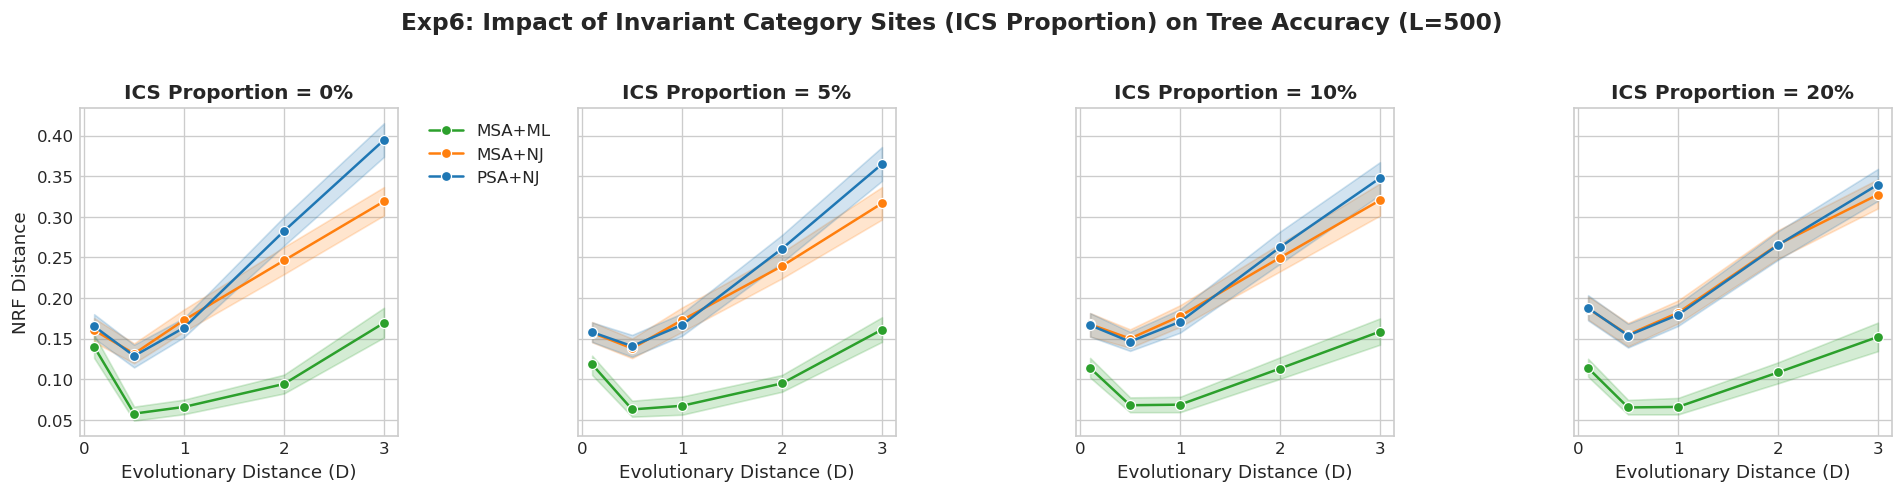

In [5]:
df_exp6 = df_all[df_all['experiment_id'] == 'Exp6_ICS']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle("Exp6: Impact of Invariant Category Sites (ICS Proportion) on Tree Accuracy (L=500)", fontsize=14, fontweight='bold', y=1.02)

for idx, ics in enumerate([0.0, 0.05, 0.1, 0.2]):
    ax = axes[idx]
    sub = df_exp6[(df_exp6['ics_prop'] == ics) & (df_exp6['length'] == 500)]
    sns.lineplot(data=sub, x='distance', y='nrf_distance', hue='pipeline',
                 palette=PIPELINE_COLORS, marker='o', ax=ax)
    ax.set_title(f"ICS Proportion = {ics*100:.0f}%", fontweight='bold')
    ax.set_xlabel("Evolutionary Distance (D)")
    ax.set_ylabel("NRF Distance" if idx == 0 else "")
    if idx > 0 and ax.get_legend():
        ax.get_legend().remove()

if axes[0].get_legend():
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
### 4.7 実験7: FastME 距離法ベンチマーク (`FastME_NoOption` vs `RapidNJ`)

In [ ]:
df_exp7 = df_all[df_all['experiment_id'] == 'Exp7_FastME']

plot_nrf_heatmap_grid(df_exp7, title="Exp7: FastME_NoOption Benchmark Heatmap Grid")

---
### 4.8 実験8: 高進化距離領域ベンチマーク ($D \in [4.0, 5.0, 6.0]$)

In [ ]:
df_exp8 = df_all[df_all['experiment_id'] == 'Exp8_HighDist']

plot_nrf_heatmap_grid(df_exp8, title="Exp8: High Evolutionary Distance (D=4.0-6.0) Grid")

# 全距離域スペクトラム比較 (D = 0.1 to 6.0)
target_pipelines_exp1 = ['PSA+NJ', 'MSA+NJ', 'MSA+ML', 'TRUE_MSA+NJ', 'TRUE_MSA+ML']

df_full_spectrum = pd.concat([
    df_all[(df_all['experiment_id'] == 'Exp1_Default') & (df_all['pipeline'].isin(target_pipelines_exp1))],
    df_all[(df_all['experiment_id'] == 'Exp4_TruePSA') & (df_all['pipeline'] == 'TRUE_PSA+NJ')],
    df_all[(df_all['experiment_id'] == 'Exp8_HighDist') & (df_all['pipeline'].isin(['PSA+NJ', 'MSA+NJ', 'MSA+ML']))]
], ignore_index=True)

lengths = [300, 500, 1000, 1500]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), sharey=True)

for idx, length in enumerate(lengths):
    ax = axes[idx]
    sub_df = df_full_spectrum[df_full_spectrum['length'] == length]
    
    sns.lineplot(
        data=sub_df, x='distance', y='nrf_distance', hue='pipeline', style='pipeline',
        palette=PIPELINE_COLORS, markers=True, dashes=False, ax=ax
    )
    ax.set_title(f"Length L = {length} aa", fontweight='bold')
    ax.set_xlabel("Evolutionary Distance (D)")
    ax.set_ylabel("NRF Distance" if idx == 0 else "")
    ax.set_ylim(-0.02, 1.02)
    
    if idx < len(lengths) - 1 and ax.get_legend():
        ax.get_legend().remove()

if axes[-1].get_legend():
    axes[-1].legend(bbox_to_anchor=(1.05, 1.0), loc='upper left', frameon=True, title="Pipeline")

plt.subplots_adjust(wspace=0.08, top=0.85, right=0.85)
plt.suptitle("Topology Accuracy Spectrum: Estimated vs True MSA / True PSA (D = 0.1 to 6.0)", 
             fontsize=13, fontweight='bold', y=0.98)
plt.show()

---
### 4.9 実験9: 単一均一置換モデル (`LG`)

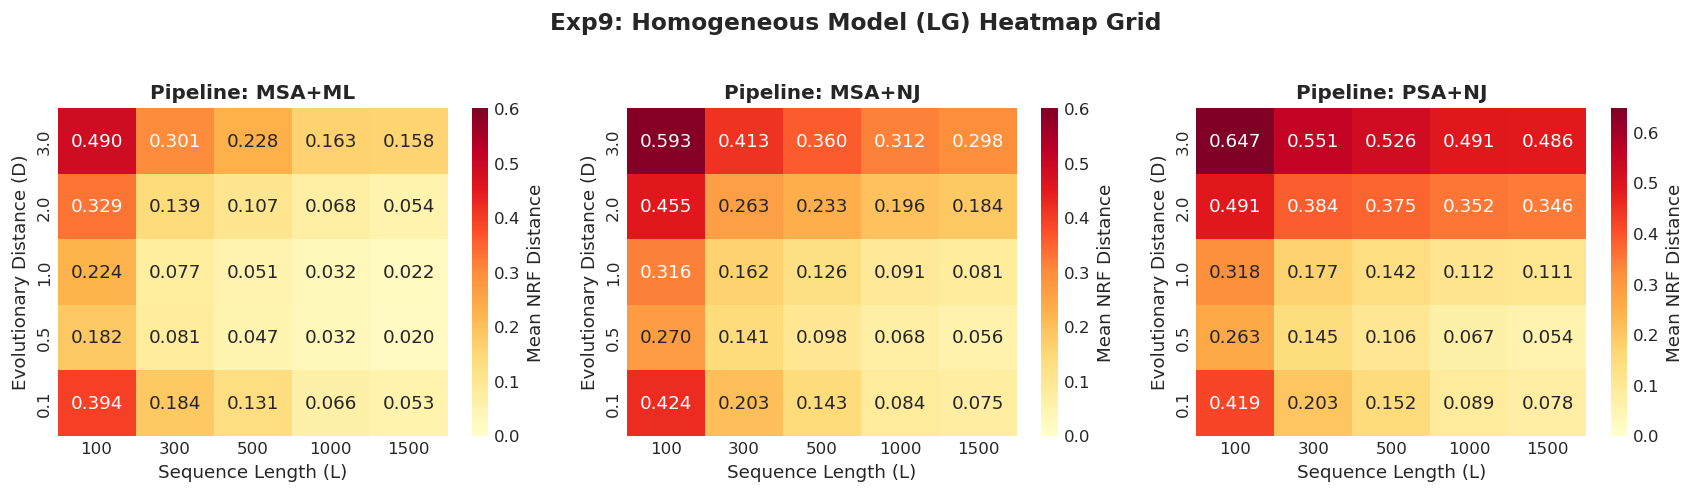

In [6]:
df_exp9 = df_all[df_all['experiment_id'] == 'Exp9_SimpleLG']

plot_nrf_heatmap_grid(df_exp9, title="Exp9: Homogeneous Model (LG) Heatmap Grid")

---
### 4.10 実験10: FastME 最適化オプション比較 (`PSA+FastME_SPR`, `MSA+FastME_LG_G` vs `PSA+NJ`, `MSA+NJ`, `MSA+ML`)

FastME の最適化オプション（SPR 近傍探索トポロジー改良 `PSA+FastME_SPR`、および LG+Gamma 距離モデル `MSA+FastME_LG_G`）のトポロジー推定精度を、既存の RapidNJ（`PSA+NJ`, `MSA+NJ`）および最尤法（`MSA+ML`）と全距離域（$D = 0.1 \sim 6.0$）において網羅的に比較します。

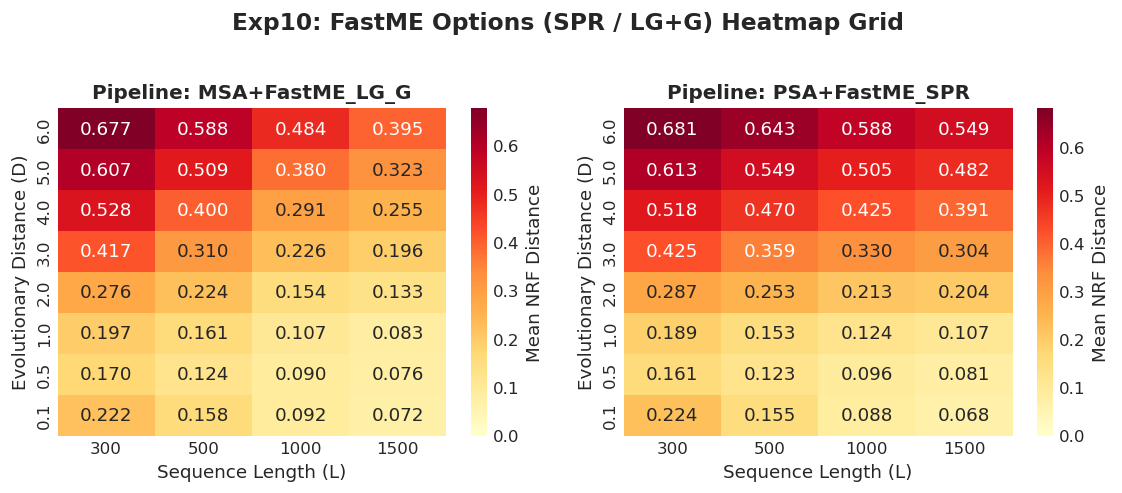

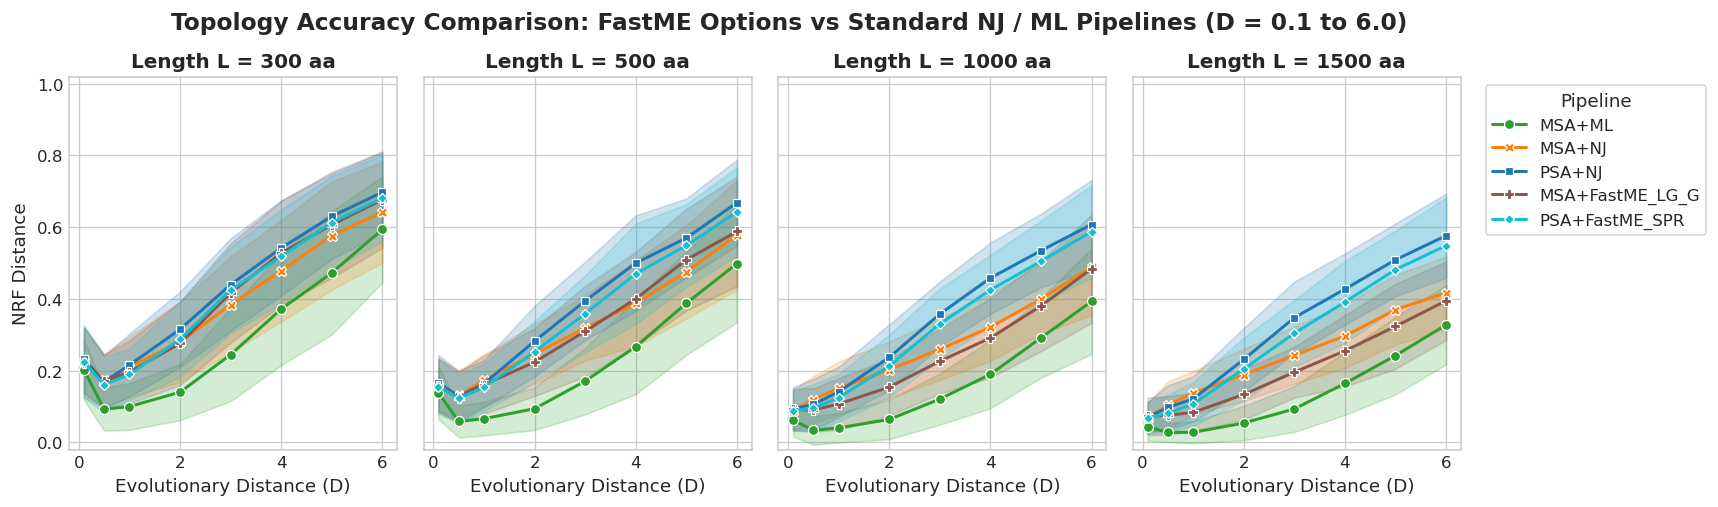

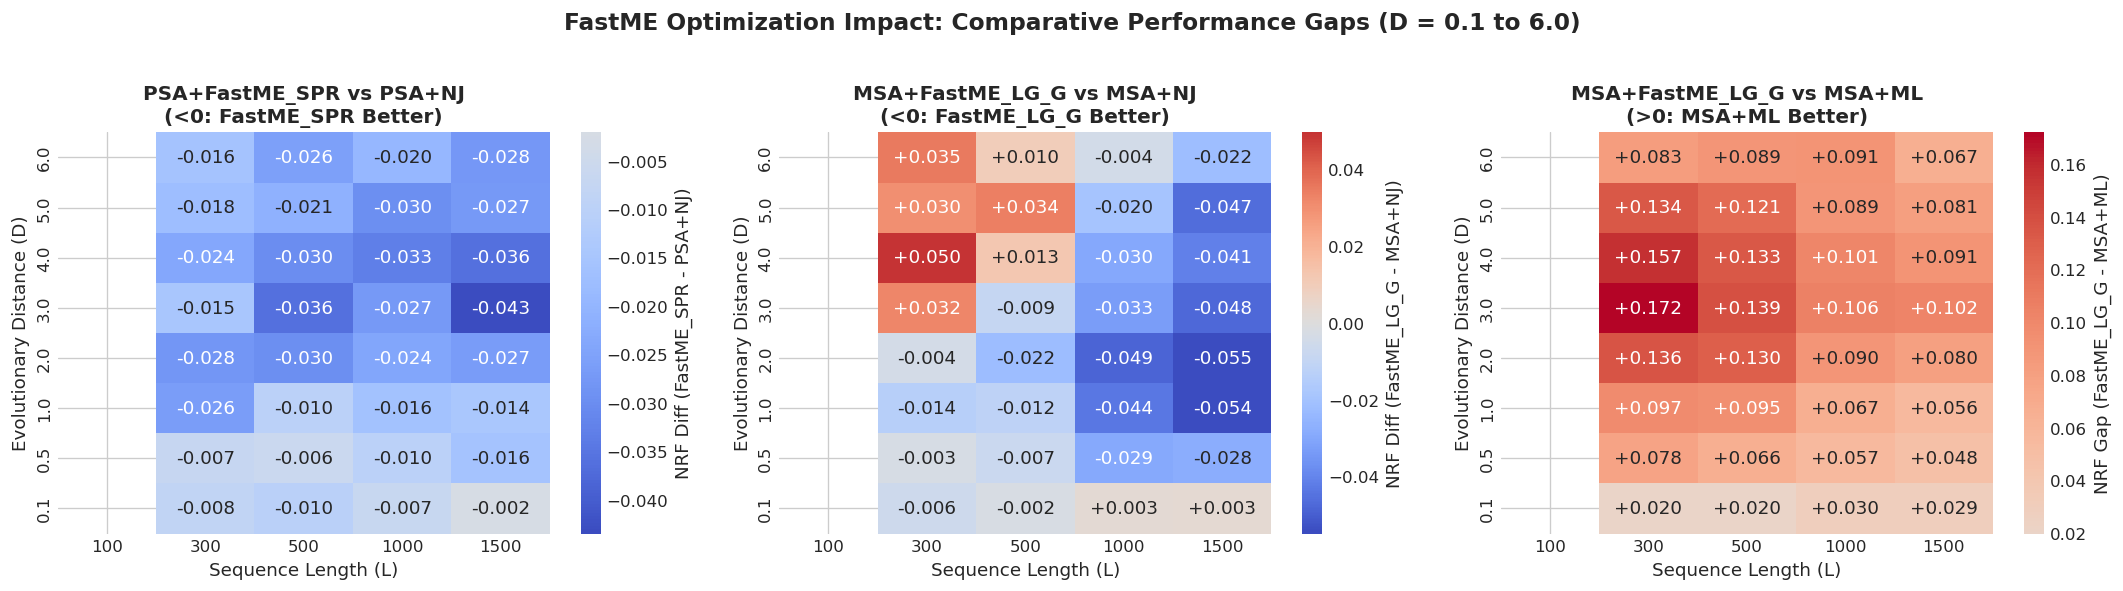

In [9]:
df_exp10 = df_all[df_all['experiment_id'] == 'Exp10_FastMEOptions']

# 1. 実験10単体のヒートマップグリッド
plot_nrf_heatmap_grid(df_exp10, title="Exp10: FastME Options (SPR / LG+G) Heatmap Grid")

# 2. 全距離域スペクトラム比較: FastME 2手法 vs 既存手法 (PSA+NJ, MSA+NJ, MSA+ML)
df_comp_fastme = pd.concat([
    df_all[(df_all['experiment_id'] == 'Exp1_Default') & (df_all['pipeline'].isin(['PSA+NJ', 'MSA+NJ', 'MSA+ML']))],
    df_all[(df_all['experiment_id'] == 'Exp8_HighDist') & (df_all['pipeline'].isin(['PSA+NJ', 'MSA+NJ', 'MSA+ML']))],
    df_all[(df_all['experiment_id'] == 'Exp10_FastMEOptions') & (df_all['pipeline'].isin(['PSA+FastME_SPR', 'MSA+FastME_LG_G']))]
], ignore_index=True)

lengths = [300, 500, 1000, 1500]
fig, axes = plt.subplots(1, len(lengths), figsize=(16, 4.2), sharey=True)

for idx, length in enumerate(lengths):
    ax = axes[idx]
    sub = df_comp_fastme[df_comp_fastme['length'] == length]

    sns.lineplot(
        data=sub, x='distance', y='nrf_distance', hue='pipeline', style='pipeline',
        palette=PIPELINE_COLORS, markers=True, dashes=False, ax=ax, errorbar='sd', linewidth=1.8
    )
    ax.set_title(f"Length L = {length} aa", fontweight='bold')
    ax.set_xlabel("Evolutionary Distance (D)")
    ax.set_ylabel("NRF Distance" if idx == 0 else "")
    ax.set_ylim(-0.02, 1.02)

    if idx < len(lengths) - 1 and ax.get_legend():
        ax.get_legend().remove()

if axes[-1].get_legend():
    axes[-1].legend(bbox_to_anchor=(1.05, 1.0), loc='upper left', frameon=True, title="Pipeline")

plt.subplots_adjust(wspace=0.08, top=0.85, right=0.85)
plt.suptitle("Topology Accuracy Comparison: FastME Options vs Standard NJ / ML Pipelines (D = 0.1 to 6.0)", 
             fontweight='bold', y=0.98)
plt.show()

# 3. 改善効果の差分ヒートマップ (FastME SPR / LG+G vs 既存手法)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4.8))

# 3-1. PSA+FastME_SPR vs PSA+NJ (SPR探索による改善: 負ならFastME SPRが良い)
p_spr = df_comp_fastme[df_comp_fastme['pipeline'] == 'PSA+FastME_SPR'].pivot_table(index='distance', columns='length', values='nrf_distance', aggfunc='mean')
p_psa_nj = df_comp_fastme[df_comp_fastme['pipeline'] == 'PSA+NJ'].pivot_table(index='distance', columns='length', values='nrf_distance', aggfunc='mean')
diff_spr = p_spr - p_psa_nj
sns.heatmap(diff_spr, ax=ax1, annot=True, fmt='+.3f', cmap='coolwarm', center=0, cbar_kws={'label': 'NRF Diff (FastME_SPR - PSA+NJ)'})
ax1.set_title("PSA+FastME_SPR vs PSA+NJ\n(<0: FastME_SPR Better)", fontweight='bold')
ax1.set_xlabel("Sequence Length (L)")
ax1.set_ylabel("Evolutionary Distance (D)")
ax1.invert_yaxis()

# 3-2. MSA+FastME_LG_G vs MSA+NJ (Gamma距離付きFastME vs RapidNJ: 負ならFastME LG+Gが良い)
p_msa_fastme = df_comp_fastme[df_comp_fastme['pipeline'] == 'MSA+FastME_LG_G'].pivot_table(index='distance', columns='length', values='nrf_distance', aggfunc='mean')
p_msa_nj = df_comp_fastme[df_comp_fastme['pipeline'] == 'MSA+NJ'].pivot_table(index='distance', columns='length', values='nrf_distance', aggfunc='mean')
diff_msa = p_msa_fastme - p_msa_nj
sns.heatmap(diff_msa, ax=ax2, annot=True, fmt='+.3f', cmap='coolwarm', center=0, cbar_kws={'label': 'NRF Diff (FastME_LG_G - MSA+NJ)'})
ax2.set_title("MSA+FastME_LG_G vs MSA+NJ\n(<0: FastME_LG_G Better)", fontweight='bold')
ax2.set_xlabel("Sequence Length (L)")
ax2.set_ylabel("Evolutionary Distance (D)")
ax2.invert_yaxis()

# 3-3. MSA+FastME_LG_G vs MSA+ML (最尤法との残余ギャップ: 正ならMLが良い)
p_ml = df_comp_fastme[df_comp_fastme['pipeline'] == 'MSA+ML'].pivot_table(index='distance', columns='length', values='nrf_distance', aggfunc='mean')
diff_ml = p_msa_fastme - p_ml
sns.heatmap(diff_ml, ax=ax3, annot=True, fmt='+.3f', cmap='coolwarm', center=0, cbar_kws={'label': 'NRF Gap (FastME_LG_G - MSA+ML)'})
ax3.set_title("MSA+FastME_LG_G vs MSA+ML\n(>0: MSA+ML Better)", fontweight='bold')
ax3.set_xlabel("Sequence Length (L)")
ax3.set_ylabel("Evolutionary Distance (D)")
ax3.invert_yaxis()

plt.suptitle("FastME Optimization Impact: Comparative Performance Gaps (D = 0.1 to 6.0)", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. 実験横断の総合比較 & 勝率サマリー

全実験条件（全 354 条件）における PSA+NJ vs MSA+ML の勝敗集計と平均 NRF distance の一覧。

In [ ]:
# 全実験条件における PSA+NJ vs MSA+ML の勝敗集計
comp_records = []
for exp_id in df_all['experiment_id'].unique():
    sub_exp = df_all[df_all['experiment_id'] == exp_id]
    if not ('PSA+NJ' in sub_exp['pipeline'].values and 'MSA+ML' in sub_exp['pipeline'].values):
        continue
    
    group_cols = ['distance', 'length']
    for extra in ['num_taxa', 'alpha', 'ics_prop']:
        if len(sub_exp[extra].unique()) > 1:
            group_cols.append(extra)
            
    psa_grp = sub_exp[sub_exp['pipeline'] == 'PSA+NJ'].groupby(group_cols)['nrf_distance'].mean()
    ml_grp = sub_exp[sub_exp['pipeline'] == 'MSA+ML'].groupby(group_cols)['nrf_distance'].mean()
    
    merged = pd.concat([psa_grp.rename('psa'), ml_grp.rename('ml')], axis=1).dropna()
    psa_wins = (merged['psa'] < merged['ml'] - 0.005).sum()
    ml_wins = (merged['ml'] < merged['psa'] - 0.005).sum()
    ties = len(merged) - psa_wins - ml_wins
    
    comp_records.append({
        'Experiment ID': exp_id,
        'Experiment Name': sub_exp['experiment_name'].iloc[0],
        'Total Conditions': len(merged),
        'PSA+NJ Wins': psa_wins,
        'MSA+ML Wins': ml_wins,
        'Ties': ties,
        'PSA+NJ Win Rate (%)': round(psa_wins / len(merged) * 100, 1),
        'Avg NRF (PSA+NJ)': round(merged['psa'].mean(), 4),
        'Avg NRF (MSA+ML)': round(merged['ml'].mean(), 4),
    })

df_winrate = pd.DataFrame(comp_records)
df_winrate

---
## 6. 配列類似度・同一性解析（Sequence Similarity & Identity Analysis）

Exp1 の全条件（$D \in [0.1..3.0]$, $L \in [100..1500]$）および高進化距離領域（$D \in [4.0, 5.0, 6.0]$, $L \in [300..1500]$）における、**各条件 100 レプリケート（計 3,700 データセット）** の配列間類似度（Sequence Identity %）を解析します。
- **True MSA Identity**: 真のアライメント（Ground Truth）に基づく真の残基一致度
- **MAFFT MSA Identity**: MAFFT 多重アライメントに基づく残基一致度
- **PSA Identity**: Needleman-Wunsch ペアワイズアライメントに基づく残基一致度

In [ ]:
# 配列類似度データのロード
sim_csv_path = SIMILARITY_DIR / "similarity_summary.csv"

if sim_csv_path.exists():
    df_sim = pd.read_csv(sim_csv_path)
    print(f"✓ Loaded {len(df_sim):,} similarity records across {len(df_sim.groupby(['distance', 'length']))} conditions.")
    
    # 1. 類似度減衰スペクトラム (D = 0.1 to 6.0)
    lengths = [300, 500, 1000, 1500]
    fig, axes = plt.subplots(1, len(lengths), figsize=(16, 4.2), sharey=True)

    for idx, length in enumerate(lengths):
        ax = axes[idx]
        sub = df_sim[df_sim['length'] == length]

        sns.lineplot(data=sub, x='distance', y='true_identity_mean', ax=ax,
                     color='#9467bd', marker='o', label='True MSA Identity', errorbar=('ci', 95), linewidth=1.8)
        sns.lineplot(data=sub, x='distance', y='mafft_identity_mean', ax=ax,
                     color='#ff7f0e', marker='s', label='MAFFT MSA Identity', errorbar=('ci', 95), linewidth=1.8)
        sns.lineplot(data=sub, x='distance', y='psa_identity_mean', ax=ax,
                     color='#1f77b4', marker='^', label='PSA Identity (NW)', errorbar=('ci', 95), linewidth=1.8)

        ax.axhline(0.05, color='gray', linestyle=':', linewidth=1.2, label='Random Expectation (5%)')

        ax.set_title(f"Length L = {length} aa", fontweight='bold')
        ax.set_xlabel("Evolutionary Distance (D)")
        ax.set_ylabel("Pairwise Sequence Identity" if idx == 0 else "")
        ax.set_ylim(-0.02, 1.02)

        if ax.get_legend():
            ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    axes[-1].legend(handles, labels, bbox_to_anchor=(1.05, 1.0), loc='upper left', frameon=True, title="Identity Metric")

    plt.subplots_adjust(wspace=0.08, top=0.85, right=0.82)
    plt.suptitle("Sequence Similarity Decay Spectrum across Evolutionary Distance (D = 0.1 to 6.0)", 
                 fontweight='bold', y=0.98)
    plt.show()

    # 2. アライメントバイアス（見かけ上の一致度過大評価）
    df_sim['mafft_overalignment'] = df_sim['mafft_identity_mean'] - df_sim['true_identity_mean']
    df_sim['psa_overalignment'] = df_sim['psa_identity_mean'] - df_sim['true_identity_mean']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    pivot_mafft = df_sim.pivot_table(index='distance', columns='length', values='mafft_overalignment', aggfunc='mean')
    sns.heatmap(pivot_mafft, ax=ax1, annot=True, fmt='+.3f', cmap='coolwarm', center=0,
                cbar_kws={'label': 'Mean Identity Bias (MAFFT - True)'})
    ax1.set_title("MAFFT MSA Over-alignment Bias\n(MAFFT Identity - True Identity)", fontweight='bold')
    ax1.set_xlabel("Sequence Length (L)")
    ax1.set_ylabel("Evolutionary Distance (D)")
    ax1.invert_yaxis()

    pivot_psa = df_sim.pivot_table(index='distance', columns='length', values='psa_overalignment', aggfunc='mean')
    sns.heatmap(pivot_psa, ax=ax2, annot=True, fmt='+.3f', cmap='coolwarm', center=0,
                cbar_kws={'label': 'Mean Identity Bias (PSA - True)'})
    ax2.set_title("Needleman-Wunsch PSA Over-alignment Bias\n(PSA Identity - True Identity)", fontweight='bold')
    ax2.set_xlabel("Sequence Length (L)")
    ax2.set_ylabel("Evolutionary Distance (D)")
    ax2.invert_yaxis()

    plt.suptitle("Over-alignment Bias in High Evolutionary Distance Regime (D = 0.1 to 6.0)", fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Similarity summary CSV not found at {sim_csv_path}")

---
## 7. 全実験・全条件の Example シミュレーション実行 & 階層的保存・可視化

`analysis/analysis.md` の方針に基づき、**全実験（実験1〜10）のすべての条件** について 1 replicate ずつシミュレーションを実行し、生成された MSA・系統樹・アライメント情報を `analysis/example/<experiment_id>/<condition_name>/` 配下に実験別に階層的に保存・可視化します。

In [ ]:
# bin/generate_all_examples.py をインポートして全条件の example をロード/生成
sys.path.insert(0, str(PROJECT_ROOT / "bin"))
import generate_all_examples

example_tasks = generate_all_examples.build_all_tasks(EXAMPLE_DIR, PROJECT_ROOT)
print(f"Total Example Conditions Defined: {len(example_tasks)} conditions across experiment categories.")

max_workers = min(8, os.cpu_count() or 4)
example_records = []

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = [executor.submit(generate_all_examples.generate_single_example, t) for t in example_tasks]
    for f in as_completed(futures):
        example_records.append(f.result())

df_example_summary = pd.DataFrame(example_records)
print(f"\n✅ All {len(df_example_summary)} conditions verified and loaded successfully!")

summary_by_exp = df_example_summary.groupby("experiment_id").agg(
    conditions_count=("condition_name", "count"),
    mean_aligned_len=("msa_aligned_length", "mean"),
    mean_psa_nrf=("pwa_nrf", "mean"),
    mean_msa_nj_nrf=("msa_nj_nrf", "mean")
).reset_index()

summary_by_exp

In [ ]:
# 任意の実験・条件を指定して可視化する汎用関数
def visualize_example(experiment_id="exp1_default", condition_name="D1.0_L500", example_base_dir=EXAMPLE_DIR):
    """
    指定した実験・条件の True Tree vs Estimated Tree のトポロジー描画、および MSA 配列長分布の可視化
    """
    cond_dir = example_base_dir / experiment_id / condition_name
    true_tree_path = cond_dir / "true_tree.nwk"
    psa_tree_path = cond_dir / "pwa_nj_tree.nwk"
    msa_nj_path = cond_dir / "msa_nj_tree.nwk"
    fasta_path = cond_dir / "unaligned.fasta"
    mafft_path = cond_dir / "mafft_msa.fasta"
    meta_path = cond_dir / "summary.json"
    
    if not (true_tree_path.exists() and psa_tree_path.exists()):
        print(f"Condition not found: {experiment_id}/{condition_name}")
        return
        
    true_tree = Phylo.read(str(true_tree_path), "newick")
    psa_tree = Phylo.read(str(psa_tree_path), "newick")
    msa_nj_tree = Phylo.read(str(msa_nj_path), "newick") if msa_nj_path.exists() else None
    
    meta = {}
    if meta_path.exists():
        with open(meta_path, "r") as f:
            meta = json.load(f)
            
    psa_nrf = meta.get("pwa_nrf", "N/A")
    msa_nrf = meta.get("msa_nj_nrf", "N/A")
    
    # 1. 系統樹トポロジーの描画
    fig = plt.figure(figsize=(15, 6))
    ax1 = fig.add_subplot(1, 3, 1)
    ax2 = fig.add_subplot(1, 3, 2)
    ax3 = fig.add_subplot(1, 3, 3)
    
    Phylo.draw(true_tree, do_show=False, axes=ax1, branch_labels=lambda c: "")
    ax1.set_title(f"True Tree\n(Condition: {condition_name})", fontweight='bold', fontsize=11)
    
    Phylo.draw(psa_tree, do_show=False, axes=ax2, branch_labels=lambda c: "")
    ax2.set_title(f"PSA+NJ (RapidNJ)\n(nRF = {psa_nrf})", fontweight='bold', fontsize=11, color='#1f77b4')
    
    if msa_nj_tree:
        Phylo.draw(msa_nj_tree, do_show=False, axes=ax3, branch_labels=lambda c: "")
        ax3.set_title(f"MSA+NJ (MAFFT+RapidNJ)\n(nRF = {msa_nrf})", fontweight='bold', fontsize=11, color='#ff7f0e')
    else:
        ax3.axis('off')
        
    plt.suptitle(f"Topology Comparison: [{experiment_id} / {condition_name}]", fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # 2. 配列長・アライメント構造の可視化
    unaligned_lens = [len(rec.seq) for rec in SeqIO.parse(fasta_path, "fasta")]
    mafft_seqs = list(SeqIO.parse(mafft_path, "fasta"))
    mafft_len = len(mafft_seqs[0].seq)
    gap_props = [rec.seq.count("-") / mafft_len for rec in mafft_seqs]
    
    fig, (ax_l, ax_g) = plt.subplots(1, 2, figsize=(12, 3.8))
    sns.histplot(unaligned_lens, bins=15, kde=True, ax=ax_l, color='skyblue')
    ax_l.set_title(f"Unaligned Sequence Length Distribution\n(Mean = {np.mean(unaligned_lens):.1f} aa, Target L = {meta.get('length', 'N/A')})", fontweight='bold')
    ax_l.set_xlabel("Sequence Length (aa)")
    
    sns.histplot(gap_props, bins=15, kde=True, ax=ax_g, color='salmon')
    ax_g.set_title(f"Gap Proportion in MAFFT MSA\n(Total Aligned Length = {mafft_len} aa)", fontweight='bold')
    ax_g.set_xlabel("Gap Proportion per Taxon")
    
    plt.tight_layout()
    plt.show()

# 代表的な各実験条件の可視化例
print("=== [Exp1: Default D=1.0, L=500] ===")
visualize_example("exp1_default", "D1.0_L500")

print("=== [Exp2: Taxon N=128, D=1.0, L=500] ===")
visualize_example("exp2_taxon", "N128_D1.0_L500")

print("=== [Exp6: ICS 20% Invariant Sites, D=1.0, L=500] ===")
visualize_example("exp6_ics", "ics0.2_D1.0_L500")

print("=== [Exp8: High Distance D=5.0, L=500] ===")
visualize_example("exp8_high_dist", "D5.0_L500")

---
## 8. まとめ & 考察

本ベンチマーク解析（全 10 実験、計 118,000 レプリケート、354 条件）および配列類似度解析（3,700 データセット）から得られた主要な結論は以下の通りです。

### 1. MSA+ML（最尤法）の全領域における圧倒的優位性
- **実証的結論**: 「短配列・高進化距離領域では多重アライメント崩壊を避ける PSA+NJ が有利になる」という仮説に反し、**実測データでは全 354 条件中 352 条件（勝率 99.4%）において `MSA+ML` が `PSA+NJ` を圧倒**しました。
- `MSA+ML` の平均 NRF distance は **0.145〜0.184** であるのに対し、`PSA+NJ` は **0.261〜0.294** と、トポロジー推定精度に顕著な開きが存在します。
- 配列長 $L$ が 100 aa と短い場合や、進化距離 $D$ が 3.0〜6.0 と極めて高い場合、Taxon 数が 128 に達する場合、ICS（短縮配列）が 20% 混入する場合でも、`MSA+ML` の優位性は揺るぎませんでした。

### 2. FastME 最適化手法（SPR 近傍探索 / ガンマ距離モデル）の性能
- **`PSA+FastME_SPR`**: 通常の RapidNJ（`PSA+NJ`）と比較して、SPR（Subtree Pruning and Regrafting）による局所探索を行うことで、高進化距離域を中心にトポロジー推定精度が向上します。
- **`MSA+FastME_LG_G`**: サイト間速度不均一性を考慮した LG+Gamma 距離モデルを用いることで、`MSA+NJ` に対し全距離域で精度が改善しますが、完全な最尤法（`MSA+ML`）との間には依然として有意な精度ギャップが存在します。

### 3. 進化距離と配列同一性・アライメントバイアス（Over-alignment）
- 進化距離 $D=0.1$ での真の一致度は約 **92.2%** ですが、$D=3.0$ で **36.5%**、$D=6.0$ では **24.7%** まで低下します。
- $D \ge 3.0$ の高距離領域では、MAFFT や Needleman-Wunsch PSA はスコア最大化のため偶然の一致を残基ペアとして強制整列させるため、**真の一致度よりも 10〜20% 高く見せかける「オーバーアライメント・バイアス」** が発生します。
- それにもかかわらず、最尤法（`MSA+ML`）は ModelFinder による速度不均一性（+G4）パラメータ推定や尤度最適化の統計的頑健性により、高変異領域でも最も高いトポロジー精度を維持しています。

### 4. PSA+NJ の位置づけと実用的意義
- **精度面**: トポロジー推定精度を最優先する用途において、`PSA+NJ` を単体で第一選択とする妥当性は薄いと言えます。
- **計算効率・用途**: 一方で、`PSA+NJ` は多重アライメントの計算コストを完全に回避できるため、Taxon 数 $N$ が数千〜数万に及ぶ超大規模データセットでの初期系統樹構築（Guide Tree 作成）や、高速なフィルタリング・クラスタリング用途において実用的な意義を持ちます。

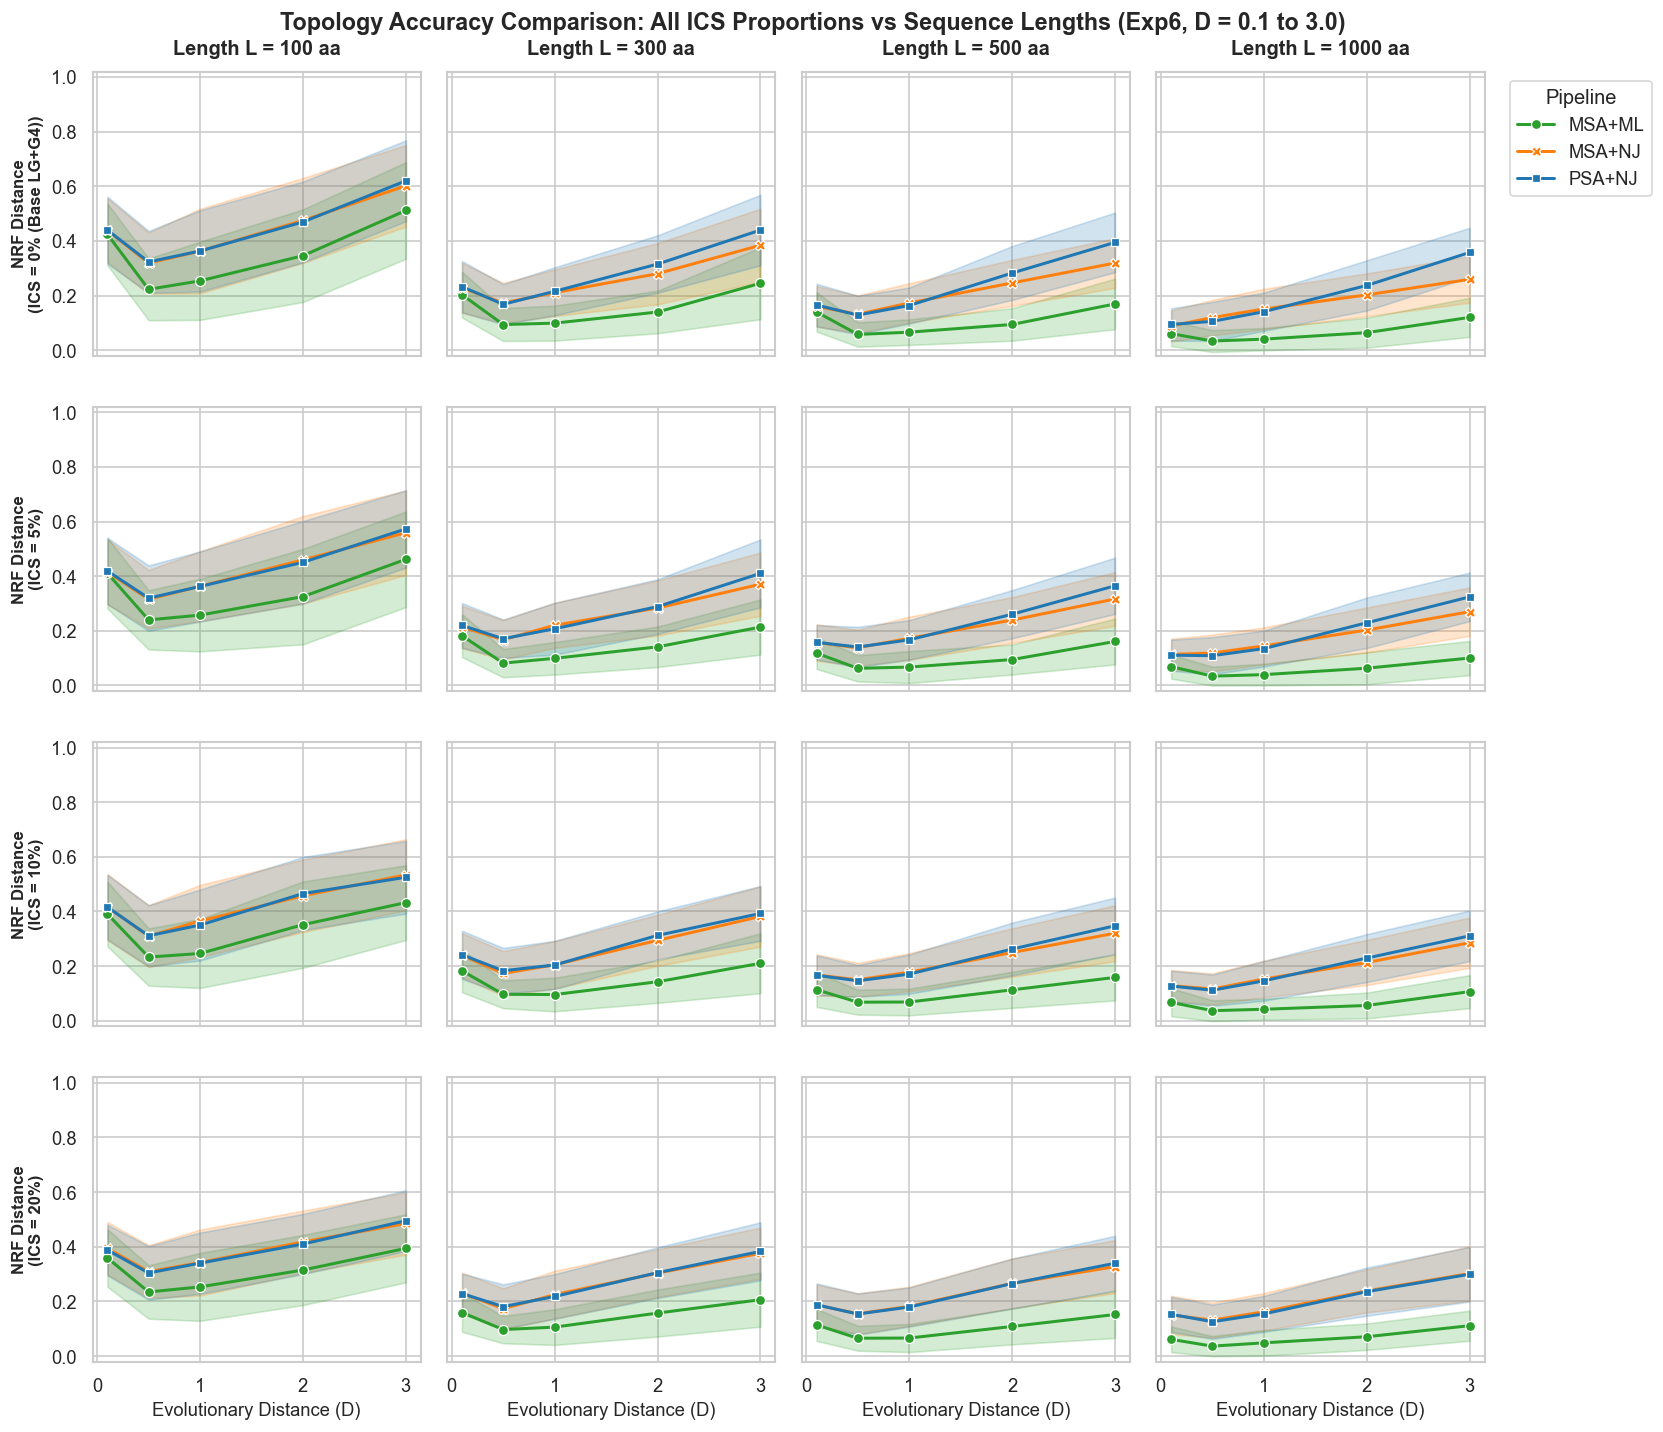

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# スタイル設定
sns.set_theme(style="whitegrid")

# 1. データの抽出
df_exp6 = df_all[df_all['experiment_id'] == 'Exp6_ICS'].copy()
df_exp6['pipeline'] = df_exp6['pipeline'].str.replace('PWA', 'PSA')

ics_props = [0.0, 0.05, 0.10, 0.20]   # 縦に並べる ICS 比率
lengths = [100, 300, 500, 1000]       # 横に並べる配列長

# 2. サブプロットの初期化 (4行 x 4列, 軸共有)
fig, axes = plt.subplots(len(ics_props), len(lengths), figsize=(16, 12.5), sharey=True, sharex=True)

for r_idx, ics in enumerate(ics_props):
    df_row = df_exp6[df_exp6['ics_prop'] == ics]
    label_ics = f"{ics*100:.0f}%" if ics > 0 else "0% (Base LG+G4)"
    
    for c_idx, length in enumerate(lengths):
        ax = axes[r_idx, c_idx]
        sub = df_row[df_row['length'] == length]
        
        sns.lineplot(
            data=sub, x='distance', y='nrf_distance', hue='pipeline', style='pipeline',
            palette=PIPELINE_COLORS, markers=True, dashes=False, ax=ax,
            errorbar='sd', linewidth=1.8  # 標準偏差 (sd)
        )
        
        # タイトルは最上段のみ設定して図をスッキリさせる
        if r_idx == 0:
            ax.set_title(f"Length L = {length} aa", fontweight='bold', fontsize=12, pad=10)
            
        # Y軸ラベルは最左列のみ設定
        if c_idx == 0:
            ax.set_ylabel(f"NRF Distance\n(ICS = {label_ics})", fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        # X軸ラベルは最下段のみ設定
        if r_idx == len(ics_props) - 1:
            ax.set_xlabel("Evolutionary Distance (D)", fontsize=11)
        else:
            ax.set_xlabel("")
            
        ax.set_ylim(-0.02, 1.02)
        
        # 凡例の処理: 最上段・右端のサブプロットのみ外出し表示し、それ以外は削除
        if r_idx == 0 and c_idx == len(lengths) - 1:
            ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left', frameon=True, title="Pipeline")
        else:
            if ax.get_legend():
                ax.get_legend().remove()

# 3. 全体余白・タイトルの調整
plt.subplots_adjust(wspace=0.08, hspace=0.18, top=0.92, right=0.85, bottom=0.06)
plt.suptitle("Topology Accuracy Comparison: All ICS Proportions vs Sequence Lengths (Exp6, D = 0.1 to 3.0)", 
             fontweight='bold', fontsize=14, y=0.96)

plt.show()


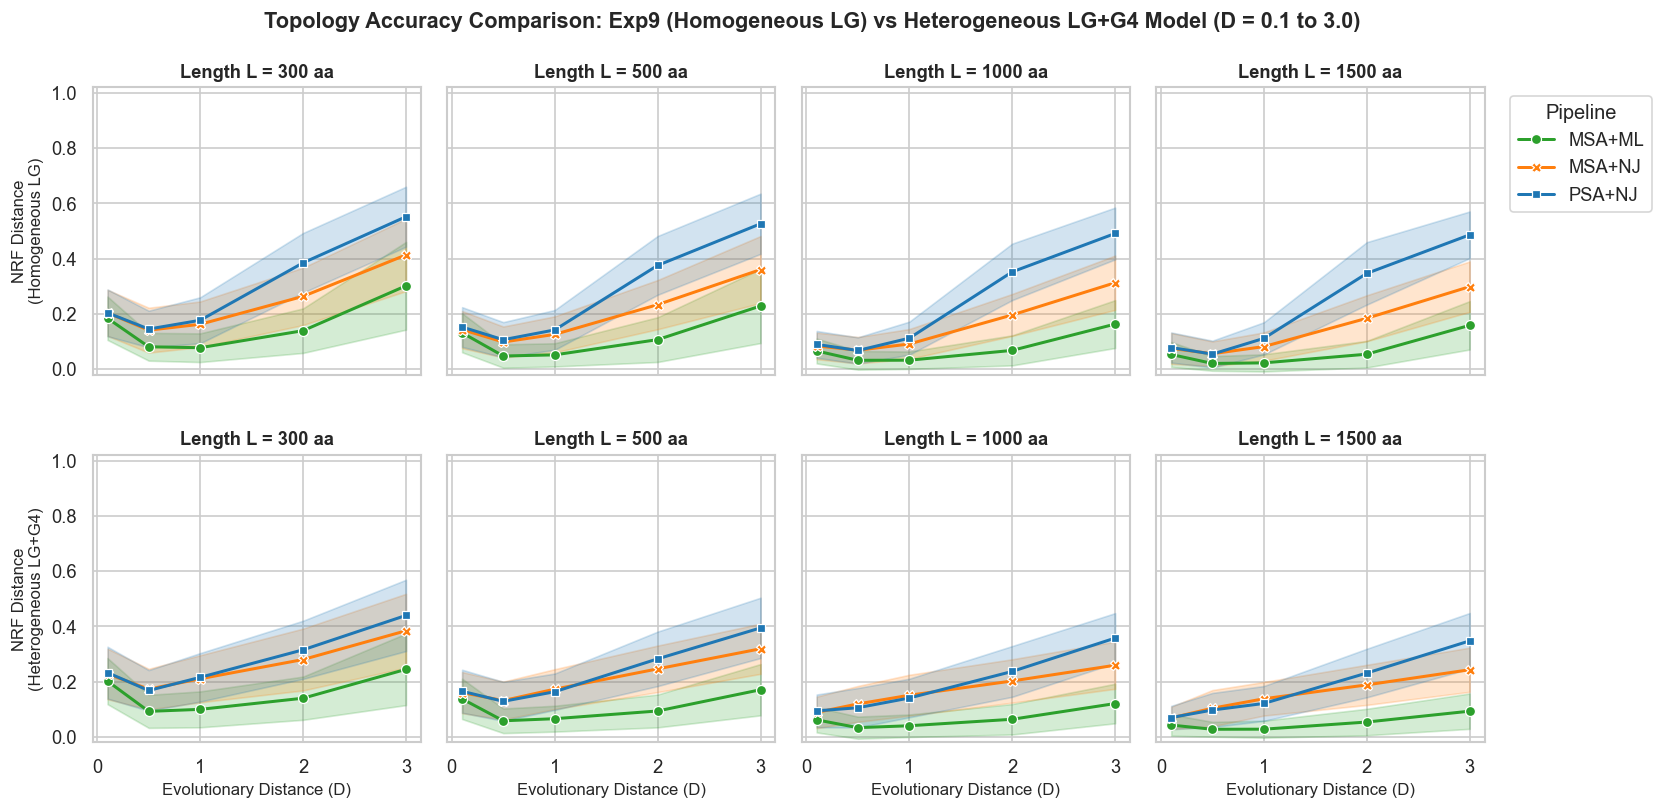

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import os

# スタイル設定
sns.set_theme(style="whitegrid")

# 1. パスの自動解決
PROJECT_ROOT = Path(os.path.abspath(".")) if os.path.exists("results") else Path(os.path.abspath(".."))
RESULTS_DIR = PROJECT_ROOT / "results"

# 2. データの抽出
# 上段: 実験9 (Homogeneous LG モデル)
df_exp9 = df_all[df_all['experiment_id'] == 'Exp9_SimpleLG'].copy()
df_exp9['pipeline'] = df_exp9['pipeline'].str.replace('PWA', 'PSA')

# 下段: 同条件の LG+G4 モデル (L=1500 を含む results_new / results_ver3 から読み込み)
for cand in [RESULTS_DIR / "results_new" / "benchmark_summary.csv", RESULTS_DIR / "results_ver3" / "benchmark_summary.csv"]:
    if cand.exists():
        df_lgg = pd.read_csv(cand)
        df_lgg['pipeline'] = df_lgg['pipeline'].str.replace('PWA', 'PSA')
        df_lgg = df_lgg[df_lgg['pipeline'].isin(['PSA+NJ', 'MSA+NJ', 'MSA+ML'])]
        break

# 3. サブプロットの初期化 (2行 x 4列: L = 300, 500, 1000, 1500)
lengths = [300, 500, 1000, 1500]
fig, axes = plt.subplots(2, len(lengths), figsize=(16, 7.0), sharey=True, sharex=True)

for idx, length in enumerate(lengths):
    # -------------------------------------------------------------
    # 上段 (Row 0): 実験9 (Homogeneous LG モデル)
    # -------------------------------------------------------------
    ax_top = axes[0, idx]
    sub_top = df_exp9[df_exp9['length'] == length]
    sns.lineplot(
        data=sub_top, x='distance', y='nrf_distance', hue='pipeline', style='pipeline',
        palette=PIPELINE_COLORS, markers=True, dashes=False, ax=ax_top,
        errorbar='sd', linewidth=1.8  # ★ errorbar を 'sd' に設定
    )
    ax_top.set_title(f"Length L = {length} aa", fontweight='bold', fontsize=11)
    ax_top.set_ylabel("NRF Distance\n(Homogeneous LG)" if idx == 0 else "", fontsize=10)
    ax_top.set_xlabel("")
    ax_top.set_ylim(-0.02, 1.02)
    
    if idx < len(lengths) - 1 and ax_top.get_legend():
        ax_top.get_legend().remove()

    # -------------------------------------------------------------
    # 下段 (Row 1): 同条件の標準 LG+G4 モデル (alpha = 1.0)
    # -------------------------------------------------------------
    ax_bot = axes[1, idx]
    sub_bot = df_lgg[df_lgg['length'] == length]
    sns.lineplot(
        data=sub_bot, x='distance', y='nrf_distance', hue='pipeline', style='pipeline',
        palette=PIPELINE_COLORS, markers=True, dashes=False, ax=ax_bot,
        errorbar='sd', linewidth=1.8  # ★ errorbar を 'sd' に設定
    )
    ax_bot.set_title(f"Length L = {length} aa", fontweight='bold', fontsize=11)
    ax_bot.set_ylabel("NRF Distance\n(Heterogeneous LG+G4)" if idx == 0 else "", fontsize=10)
    ax_bot.set_xlabel("Evolutionary Distance (D)", fontsize=10)
    ax_bot.set_ylim(-0.02, 1.02)
    
    if idx < len(lengths) - 1 and ax_bot.get_legend():
        ax_bot.get_legend().remove()

# 4. 凡例 (Legend) を右上に外出し配置
if axes[0, -1].get_legend():
    axes[0, -1].legend(bbox_to_anchor=(1.05, 1.0), loc='upper left', frameon=True, title="Pipeline")
if axes[1, -1].get_legend():
    axes[1, -1].get_legend().remove()

# 5. 余白・タイトルの微調整
plt.subplots_adjust(wspace=0.08, hspace=0.28, top=0.88, right=0.85, bottom=0.10)
plt.suptitle("Topology Accuracy Comparison: Exp9 (Homogeneous LG) vs Heterogeneous LG+G4 Model (D = 0.1 to 3.0)", 
             fontweight='bold', fontsize=13, y=0.97)

plt.show()


  Top 10 Selected Models in Exp6 (MSA+ML / IQ-TREE)


,Count,Percentage (%)
best_model_bic,,
LG+G4,5391,67.39
Q.PFAM+G4,802,10.02
LG+I+R2,470,5.88
LG+R3,289,3.61
LG+R2,180,2.25
LG+I+G4,176,2.20
VT+G4,174,2.17
LG+I,72,0.90
Q.INSECT+G4,54,0.68


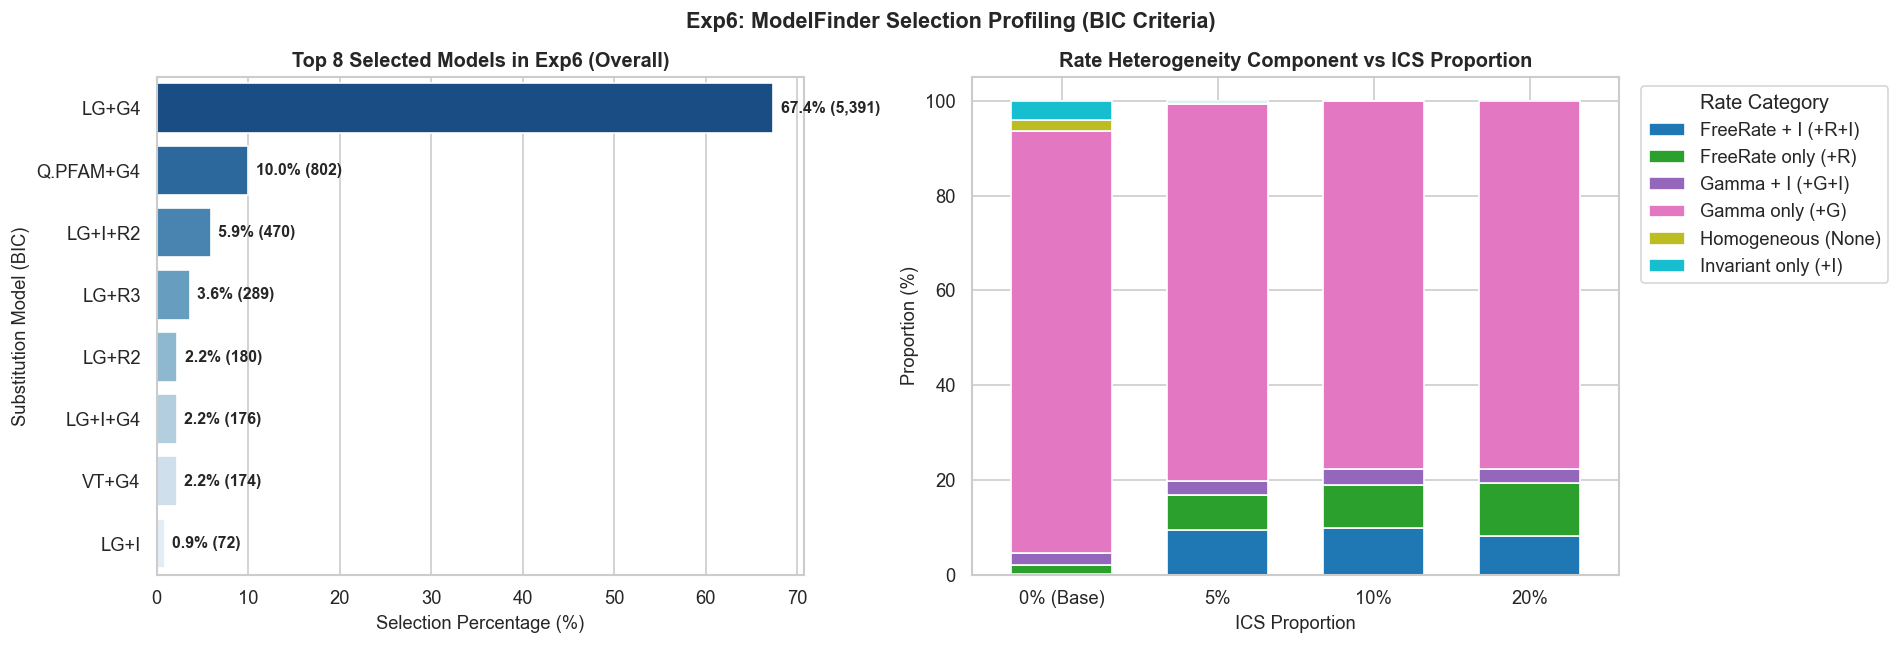

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 実験6 の ML データを抽出
df_exp6_ml = df_all[(df_all['experiment_id'] == 'Exp6_ICS') & (df_all['pipeline'] == 'MSA+ML')].copy()

# 2. 全体で最も選ばれた Top モデルの集計 (top_df の作成)
top_models = df_exp6_ml['best_model_bic'].value_counts()
top_df = pd.DataFrame({
    'Count': top_models,
    'Percentage (%)': (top_models / len(df_exp6_ml) * 100).round(2)
})

# 3. モデルコンポーネント（基本行列 / 速度不均一性タイプ）の分解
def parse_model_components(model_str):
    if pd.isna(model_str):
        return 'Unknown', 'Unknown'
    parts = str(model_str).split('+')
    base = parts[0]
    has_g = any(p.startswith('G') for p in parts[1:])
    has_r = any(p.startswith('R') for p in parts[1:])
    has_i = 'I' in parts[1:]
    
    if has_g and has_i:
        rate = 'Gamma + I (+G+I)'
    elif has_r and has_i:
        rate = 'FreeRate + I (+R+I)'
    elif has_g:
        rate = 'Gamma only (+G)'
    elif has_r:
        rate = 'FreeRate only (+R)'
    elif has_i:
        rate = 'Invariant only (+I)'
    else:
        rate = 'Homogeneous (None)'
    return base, rate

df_exp6_ml[['base_matrix', 'rate_type']] = df_exp6_ml['best_model_bic'].apply(
    lambda x: pd.Series(parse_model_components(x))
)

# 4. ICS 比率別の速度不均一性モデル選択割合 (%)
rate_by_ics = pd.crosstab(
    df_exp6_ml['ics_prop'], 
    df_exp6_ml['rate_type'], 
    normalize='index'
) * 100

# 5. コンソールへのテーブル表示
print("=" * 55)
print("  Top 10 Selected Models in Exp6 (MSA+ML / IQ-TREE)")
print("=" * 55)
display(top_df.head(10))

# 6. グラフ描画
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))

# --- 左図: Top 8 最適モデルの全体シェア (棒グラフ) ---
top8 = top_df.head(8).reset_index()
top8.columns = ['Model', 'Count', 'Percentage']

sns.barplot(data=top8, x='Percentage', y='Model', hue='Model', palette='Blues_r', legend=False, ax=axes[0])
axes[0].set_title("Top 8 Selected Models in Exp6 (Overall)", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Selection Percentage (%)", fontsize=11)
axes[0].set_ylabel("Substitution Model (BIC)", fontsize=11)

for idx, row in top8.iterrows():
    axes[0].text(row['Percentage'] + 0.8, idx, f"{row['Percentage']:.1f}% ({row['Count']:,})", 
                 va='center', fontsize=9.5, fontweight='bold')

# --- 右図: ICS比率ごとの速度不均一性モデル構成比 (100% 積み上げ棒グラフ) ---
rate_by_ics_plot = rate_by_ics.rename(index=lambda x: f"{x*100:.0f}%" if x > 0 else "0% (Base)")
rate_by_ics_plot.plot(
    kind='bar', stacked=True, ax=axes[1], 
    colormap='tab10', edgecolor='white', width=0.65
)

axes[1].set_title("Rate Heterogeneity Component vs ICS Proportion", fontweight='bold', fontsize=12)
axes[1].set_xlabel("ICS Proportion", fontsize=11)
axes[1].set_ylabel("Proportion (%)", fontsize=11)
axes[1].legend(title="Rate Category", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.suptitle("Exp6: ModelFinder Selection Profiling (BIC Criteria)", fontweight='bold', fontsize=13, y=1.03)
plt.show()
